In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LEARNING_RATE = 0.001
BATCH_SIZE = 64
NUM_EPOCHS = 5

In [3]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [4]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=data_transforms['train'])
val_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss, total_acc = 0, 0
    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        total_acc += torch.sum(preds == labels.data)
    return total_loss / len(dataloader.dataset), total_acc.double() / len(dataloader.dataset)

In [6]:
def evaluate_epoch(model, dataloader, criterion):
    model.eval()
    total_loss, total_acc = 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total_acc += torch.sum(preds == labels.data)
    return total_loss / len(dataloader.dataset), total_acc.double() / len(dataloader.dataset)

In [7]:
def plot_history(history, model_name):
    # Convert accuracy tensors to float (CPU) if needed
    def to_float_list(lst):
        return [x.cpu().item() if torch.is_tensor(x) else x for x in lst]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{model_name} - Loss Over Epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax2.plot(to_float_list(history['train_acc']), label='Train Accuracy')
    ax2.plot(to_float_list(history['val_acc']), label='Validation Accuracy')
    ax2.set_title(f'{model_name} - Accuracy Over Epochs')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    plt.show()

In [8]:
print(f"\n--- Initializing model for selective fine-tuning ---")
model_sft = models.resnet18(weights = models.ResNet18_Weights.DEFAULT)


--- Initializing model for selective fine-tuning ---


In [9]:
# Freeze all the parameters first
for param in model_sft.parameters():
    param.requires_grad = False
    
# Unfreeze the parameters of the final block (layer4) and the new classifier.
# We iterate through the named parameters to identify layers by their names.
for name, param in model_sft.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

# Replace the final fully connected layer (the new fc layer will have requires_grad = True by default)
num_ftrs = model_sft.fc.in_features
model_sft.fc = nn.Linear(num_ftrs, 10)

model_sft = model_sft.to(device = DEVICE)

In [10]:
print(f"\nParameters to be trained: ")
params_to_update = []

for name, param in model_sft.named_parameters():
    if param.requires_grad:
        params_to_update.append(param)
        print(f"\t{name}")


Parameters to be trained: 
	layer4.0.conv1.weight
	layer4.0.bn1.weight
	layer4.0.bn1.bias
	layer4.0.conv2.weight
	layer4.0.bn2.weight
	layer4.0.bn2.bias
	layer4.0.downsample.0.weight
	layer4.0.downsample.1.weight
	layer4.0.downsample.1.bias
	layer4.1.conv1.weight
	layer4.1.bn1.weight
	layer4.1.bn1.bias
	layer4.1.conv2.weight
	layer4.1.bn2.weight
	layer4.1.bn2.bias
	fc.weight
	fc.bias


In [11]:
optimizer = torch.optim.Adam(params = params_to_update, lr = LEARNING_RATE / 10)
criterion = nn.CrossEntropyLoss()

In [12]:
print("\n--- Starting Training: Selective Fine-Tuning ---")
history_sft = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    train_loss, train_acc = train_epoch(model_sft, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate_epoch(model_sft, val_loader, criterion)

    history_sft['train_loss'].append(train_loss)
    history_sft['train_acc'].append(train_acc)
    history_sft['val_loss'].append(val_loss)
    history_sft['val_acc'].append(val_acc)

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val. Loss: {val_loss:.4f} | Val. Acc: {val_acc*100:.2f}%")


--- Starting Training: Selective Fine-Tuning ---

Epoch 1/5


Evaluating: 100%|██████████| 157/157 [00:21<00:00,  7.24it/s]


  Train Loss: 0.4305 | Train Acc: 85.63%
  Val. Loss: 0.2927 | Val. Acc: 89.86%

Epoch 2/5


Evaluating: 100%|██████████| 157/157 [00:29<00:00,  5.33it/s]


  Train Loss: 0.2031 | Train Acc: 93.27%
  Val. Loss: 0.2686 | Val. Acc: 91.05%

Epoch 3/5


...

  Train Loss: 0.1220 | Train Acc: 96.15%
  Val. Loss: 0.2633 | Val. Acc: 91.11%

Epoch 4/5


Evaluating: 100%|██████████| 157/157 [00:22<00:00,  7.11it/s]


  Train Loss: 0.0798 | Train Acc: 97.50%
  Val. Loss: 0.2837 | Val. Acc: 91.38%

Epoch 5/5


Evaluating: 100%|██████████| 157/157 [00:21<00:00,  7.45it/s]

  Train Loss: 0.0517 | Train Acc: 98.43%
  Val. Loss: 0.2815 | Val. Acc: 91.65%


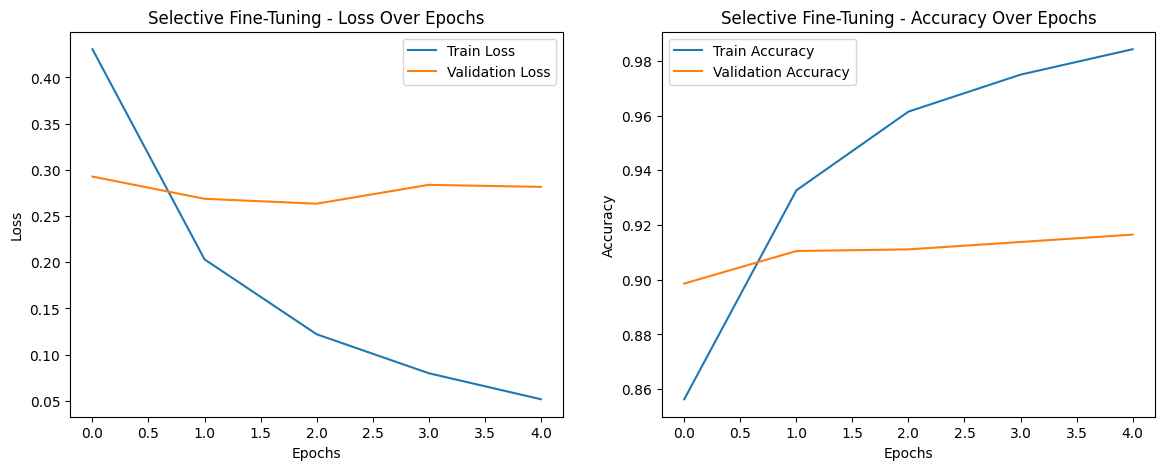

In [13]:
plot_history(history_sft, "Selective Fine-Tuning")